<a href="https://colab.research.google.com/github/ruchising/mri_gan_deepfake/blob/patch-1/import_libraries.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
import os
import numpy as np
import random
from PIL import Image, ImageEnhance


# keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Flatten, Dropout
from tensorflow.keras.preprocessing.image import load_img
from tensorflow.keras.optimizers import Adam  # for using Adam optimizer
from tensorflow.keras.applications import VGG16  # for using VGG16 as a base model
from sklearn.utils import shuffle  # for shuffling the data


In [5]:
#direction for training and testing data
train_dir = r'/content/drive/MyDrive/tumor_detection_using_deepLearning.ipybn/MRI Sample/Training'
test_dir= r'/content/drive/MyDrive/tumor_detection_using_deepLearning.ipybn/MRI Sample/Testing'
# load and shuffle the train data
train_path = []
train_labels =[]
# for label in os.listdir(train_dir):
#     print(label)

# for label in os.listdir(train_dir):
#     for image in os.listdir(os.path.join(train_dir,label)):
#         print(image)

for label in os.listdir(train_dir):
    for image in os.listdir(os.path.join(train_dir,label)):
        train_path.append(os.path.join(train_dir,label,image))
        train_labels.append(label)

train_path,train_labels = shuffle(train_path,train_labels)
train_path

['/content/drive/MyDrive/tumor_detection_using_deepLearning.ipybn/MRI Sample/Training/pituitary/Tr-pi_0050.jpg',
 '/content/drive/MyDrive/tumor_detection_using_deepLearning.ipybn/MRI Sample/Training/pituitary/Tr-pi_0200.jpg',
 '/content/drive/MyDrive/tumor_detection_using_deepLearning.ipybn/MRI Sample/Training/pituitary/Tr-pi_0026.jpg',
 '/content/drive/MyDrive/tumor_detection_using_deepLearning.ipybn/MRI Sample/Training/pituitary/Tr-pi_0128.jpg',
 '/content/drive/MyDrive/tumor_detection_using_deepLearning.ipybn/MRI Sample/Training/pituitary/Tr-pi_0196.jpg',
 '/content/drive/MyDrive/tumor_detection_using_deepLearning.ipybn/MRI Sample/Training/pituitary/Tr-pi_0099.jpg',
 '/content/drive/MyDrive/tumor_detection_using_deepLearning.ipybn/MRI Sample/Training/pituitary/Tr-pi_0064.jpg',
 '/content/drive/MyDrive/tumor_detection_using_deepLearning.ipybn/MRI Sample/Training/pituitary/Tr-pi_0106.jpg',
 '/content/drive/MyDrive/tumor_detection_using_deepLearning.ipybn/MRI Sample/Training/pituitary/

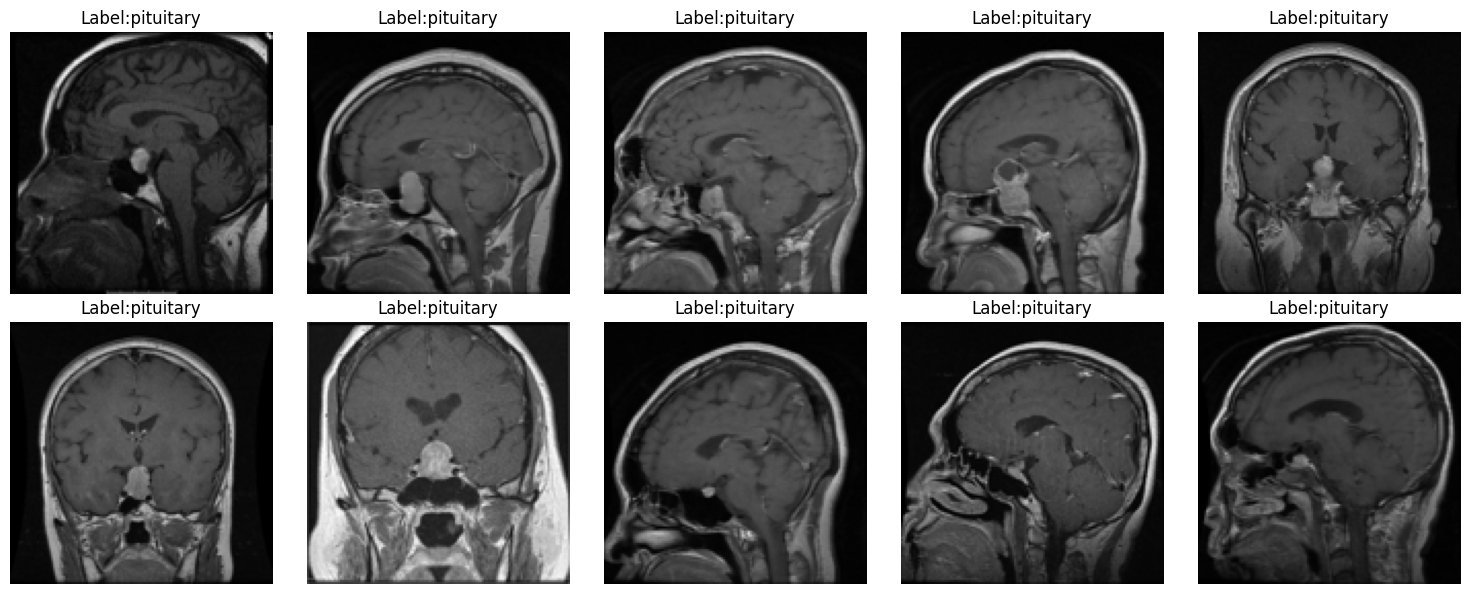

In [6]:
import random
import matplotlib.pyplot as plt

# select random indicies for 10 images
random_indices = random.sample(range(len(train_path)),10)
# random_indices

# Create a figure to display images in 2 rows
fig, axes = plt.subplots(2,5,figsize=(15,6))
axes = axes.flatten()

# loop through the random indices and display images
for i, idx in enumerate(random_indices):
    img_path = train_path[idx]
    img = Image.open(img_path)
    img = img.resize((128,128))

    # display images
    axes[i].imshow(img)
    axes[i].axis("off")
    axes[i].set_title(f"Label:{train_labels[idx]}")

plt.tight_layout()
plt.show()



In [21]:
import numpy as np
import random
import os
from PIL import Image, ImageEnhance
from tensorflow.keras.utils import load_img, img_to_array

# --- Image Size ---
IMAGE_SIZE = 128

# --- Augmentation Function ---
def augment_image(image):
    image = Image.fromarray(np.uint8(image))
    image = ImageEnhance.Brightness(image).enhance(random.uniform(0.8, 1.2))
    image = ImageEnhance.Contrast(image).enhance(random.uniform(0.8, 1.2))
    image = np.array(image) / 255.0
    return image

# --- Load and Augment Images ---
def open_images(paths):
    images = []
    for path in paths:
        img = load_img(path, target_size=(IMAGE_SIZE, IMAGE_SIZE))
        img = img_to_array(img)
        img = augment_image(img)
        images.append(img)
    return np.array(images)

# --- Label Encoding Function ---
def encode_label(labels, class_names):
    return [class_names.index(label) for label in labels]

# --- Data Generator ---
def datagen(paths, labels, batch_size=12, epochs=1, train_dir=None):
    class_names = sorted(os.listdir(train_dir))  # class list used for encoding
    for _ in range(epochs):
        for i in range(0, len(paths), batch_size):
            batch_paths = paths[i:i + batch_size]
            batch_labels = labels[i:i + batch_size]
            batch_images = open_images(batch_paths)
            encoded_labels = encode_label(batch_labels, class_names)
            yield batch_images, np.array(encoded_labels)


In [22]:
# model architecture (12,128,3)
IMAGE_SIZE=128
base_model = VGG16(input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3), include_top=False, weights='imagenet')

# Freeze all layers of the VGG16 BASE MODEL
for layer in base_model.layers:
    layer.trainable = False

# set only the last few layers
base_model.layers[-2].trainable = True
base_model.layers[-3].trainable = True
base_model.layers[-4].trainable = True

# Build Model
model = Sequential()
model.add(Input(shape =(IMAGE_SIZE,IMAGE_SIZE,3)))   #input layer
model.add(base_model) #VGG16 base model
model.add(Flatten()) #Flatten layer
model.add(Dropout(0.3)) # Dropout layer
model.add(Dense(128,activation = 'relu'))  # Dense layer
model.add(Dropout(0.2))

model.add(Dense(3,activation='softmax')) # output layer
model.add(Dense(len(os.listdir(train_dir)),activation='softmax'))


# compile the model
model.compile(optimizer=Adam(learning_rate=0.0001),loss='Sparse_categorical_crossentropy',metrics=['Sparse_categorical_crossentropy_accuracy'])

# parameters
batch_size = 20
steps=int(len(train_path)/batch_size)
epochs = 5

# train model
history = model.fit(
    datagen(train_path,train_labels,batch_size=batch_size,epochs=epochs),
    steps_per_epoch=steps,
    epochs=epochs

)


ValueError: 'pituitary' is not in list